<a href="https://colab.research.google.com/github/somar9/Neutrino-Oscillation-Project/blob/ND-simulation---Gaussian/4_Flavour_oscillation(4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Clone github repository for neutrino oscilation probability
!git clone https://github.com/mbustama/NuOscProbExact.git
%cd NuOscProbExact/src
%ls


Cloning into 'NuOscProbExact'...
remote: Enumerating objects: 741, done.
remote: Counting objects: 100% (155/155), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 741 (delta 110), reused 83 (delta 44), pack-reused 586 (from 1)
Receiving objects: 100% (741/741), 808.67 KiB | 5.35 MiB/s, done.
Resolving deltas: 100% (388/388), done.
/content/NuOscProbExact/src
globaldefs.py       hamiltonians3nu.py  oscprob3nu.py
hamiltonians2nu.py  oscprob2nu.py


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import curve_fit

import matplotlib as mpl
mpl.rcParams.update({
    "figure.figsize":   (10, 6),
    "font.size":        16,
    "axes.titlesize":   22,
    "axes.labelsize":   18,
    "xtick.labelsize":  14,
    "ytick.labelsize":  14,
    "legend.fontsize":  16,
    "grid.linewidth":   0.8
})

In [ ]:
# Constants
CONV_KM_TO_INV_EV = 5.067731e9      # km to eV⁻¹
VCC_EARTH_CRUST = 7.6e-14           # Matter potential (eV)


def mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14):
    c12, c13, c23, c14, c24, c34 = np.cos([theta12, theta13, theta23, theta14, theta24, theta34])
    s12, s13, s23, s14, s24, s34 = np.sin([theta12, theta13, theta23, theta14, theta24, theta34])
    U = np.array([
        [c12 * c13 * c14, s12 * c13 * c14, s13 * c14 * np.exp(-1j * delta13), s14 * np.exp(-1j * delta14)],
        [-s12 * c23 - c12 * s13 * s23 * np.exp(1j * delta13),
         c12 * c23 - s12 * s13 * s23 * np.exp(1j * delta13),
         c13 * s23,
         s24 * c13],
        [s12 * s23 - c12 * s13 * c23 * np.exp(1j * delta13),
         -c12 * s23 - s12 * s13 * c23 * np.exp(1j * delta13),
         c13 * c23,
         c24 * s34],
        [0, 0, 0, c34]
    ])
    return U

def hamiltonian_4nu_vacuum(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14, D21, D31, D41, E):
    m2_diag = np.diag([0, D21, D31, D41])
    U = mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14)
    return U @ m2_diag @ np.conj(U.T) / (2 * E)

def hamiltonian_4nu_matter(H_vacuum, E, VCC):
    return H_vacuum + np.diag([VCC, 0, 0, 0])


def probabilities_4nu_vacuum(H_vacuum, baseline):
    S = expm(-1j * H_vacuum * baseline)
    return np.abs(S[1, 1])**2, np.abs(S[1, 0])**2, np.abs(S[1, 2])**2, np.abs(S[1, 3])**2

def probabilities_4nu_matter(H_matter, baseline):
    S = expm(-1j * H_matter * baseline)
    return np.abs(S[1, 1])**2, np.abs(S[1, 0])**2, np.abs(S[1, 2])**2, np.abs(S[1, 3])**2

def compute_probabilities(baseline, energy_values, matter=False):
    Prob_mm, Prob_me, Prob_mt, Prob_ms = [], [], [], []
    for E in energy_values:
        H_vacuum = hamiltonian_4nu_vacuum(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14, D21, D31, D41, E)
        if matter:
            H = hamiltonian_4nu_matter(H_vacuum, E, VCC_EARTH_CRUST)
            Pmm, Pme, Pmt, Pms = probabilities_4nu_matter(H, baseline * CONV_KM_TO_INV_EV)
        else:
            Pmm, Pme, Pmt, Pms = probabilities_4nu_vacuum(H_vacuum, baseline * CONV_KM_TO_INV_EV)
        Prob_mm.append(Pmm)
        Prob_me.append(Pme)
        Prob_mt.append(Pmt)
        Prob_ms.append(Pms)
    return np.array(Prob_mm), np.array(Prob_me), np.array(Prob_mt), np.array(Prob_ms)


bin_centers = np.array([0.375, 0.875, 1.05, 1.15, 1.25, 1.35, 1.45, 1.55, 1.65, 1.75, 1.85, 1.95, 2.125, 2.375, 2.6375, 2.8875, 3.25, 3.75, 4.5]) * 1e9
bin_edges = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775, 3, 3.5, 4, 5]) * 1e9
counts_nd = np.array([5, 42, 72, 96, 120, 148, 170, 192, 208, 214, 212, 204, 170, 112, 66, 36, 16, 5, 1])

def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

popt_nd, _ = curve_fit(gaussian, bin_centers, counts_nd, p0=[np.max(counts_nd), 2.5e9, 0.5e9])

Length_near = 1
Length_far = 810

theta12, theta13, theta23 = np.radians([33.82, 8.61, 48.3])
theta14, theta24, theta34 = np.radians([10.0, 5.0, 2.0])
delta13, delta14 = np.radians([0, 0])
D21, D31, D41 = [7.39e-5, 2.525e-3, 1.0]

# Compute probabilities
prob_mm_far_vac, *_ = compute_probabilities(Length_far, bin_centers, matter=False)
prob_mm_far_matter, *_ = compute_probabilities(Length_far, bin_centers, matter=True)

# Apply survival probability to fitted spectrum
oscillated_fd_vac = gaussian(bin_centers, *popt_nd) * prob_mm_far_vac / np.max(prob_mm_far_vac)
oscillated_fd_matter = gaussian(bin_centers, *popt_nd) * prob_mm_far_matter / np.max(prob_mm_far_matter)

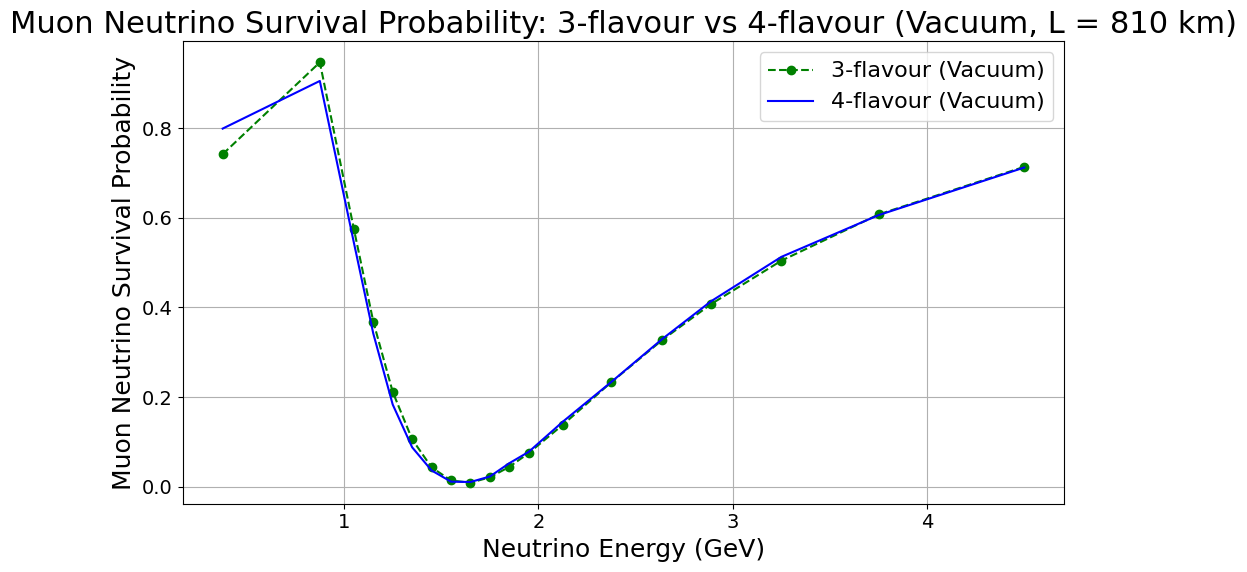

In [ ]:
def mixing_matrix_3nu(theta12, theta13, theta23, delta13):
    c12, c13, c23 = np.cos([theta12, theta13, theta23])
    s12, s13, s23 = np.sin([theta12, theta13, theta23])
    U = np.array([
        [c12 * c13, s12 * c13, s13 * np.exp(-1j * delta13)],
        [-s12 * c23 - c12 * s13 * s23 * np.exp(1j * delta13),
         c12 * c23 - s12 * s13 * s23 * np.exp(1j * delta13),
         c13 * s23],
        [s12 * s23 - c12 * s13 * c23 * np.exp(1j * delta13),
         -c12 * s23 - s12 * s13 * c23 * np.exp(1j * delta13),
         c13 * c23]
    ])
    return U

def hamiltonian_3nu_vacuum(theta12, theta13, theta23, delta13, D21, D31, E):
    m2_diag = np.diag([0, D21, D31])
    U = mixing_matrix_3nu(theta12, theta13, theta23, delta13)
    return U @ m2_diag @ np.conj(U.T) / (2 * E)

def probabilities_3nu(H_vacuum, baseline):
    S = expm(-1j * H_vacuum * baseline)
    Pmm = np.abs(S[1, 1])**2
    return Pmm

def compute_probabilities_3flavour(baseline, energy_values):
    prob_mm = []
    for E in energy_values:
        H = hamiltonian_3nu_vacuum(theta12, theta13, theta23, delta13, D21, D31, E)
        Pmm = probabilities_3nu(H, baseline * CONV_KM_TO_INV_EV)
        prob_mm.append(Pmm)
    return np.array(prob_mm)


# Compute 3-flavour probabilities
prob_mm_3flavour = compute_probabilities_3flavour(Length_far, bin_centers)

# Plot 3ν vs 4ν vacuum
plt.figure(figsize=(10, 6))
plt.plot(bin_centers * 1e-9, prob_mm_3flavour, 'g--o', label='3-flavour (Vacuum)')
plt.plot(bin_centers * 1e-9, prob_mm_far_vac, 'b-', label='4-flavour (Vacuum)')
plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel("Muon Neutrino Survival Probability")
plt.title("Muon Neutrino Survival Probability: 3-flavour vs 4-flavour (Vacuum, L = 810 km)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
x = np.linspace(bin_centers[0], bin_centers[-1], 500)  # Smooth x for Gaussian curves

def osc_probability_nu(model, case, length, transition):
    energy = bin_centers * 1e9  # eV
    probabilities = []

    for E in energy:
        if model == '3flavour':
            # 3-flavour Hamiltonian
            H = hamiltonian_3nu_vacuum(theta12, theta13, theta23, delta13, D21, D31, E)
            if case == 'matter':
                # Optional: you can implement matter effects here too
                raise NotImplementedError("3-flavour matter not implemented yet")
            S = expm(-1j * H * length * CONV_KM_TO_INV_EV)
            if transition == 'mm':
                prob = np.abs(S[1, 1])**2
            elif transition == 'me':
                prob = np.abs(S[1, 0])**2
            elif transition == 'mt':
                prob = np.abs(S[1, 2])**2

        elif model == '4flavour':
            H_vacuum = hamiltonian_4nu_vacuum(theta12, theta13, theta23,
                                              theta14, theta24, theta34,
                                              delta13, delta14, D21, D31, D41, E)
            if case == 'vacuum':
                S = expm(-1j * H_vacuum * length * CONV_KM_TO_INV_EV)
            elif case == 'matter':
                H = hamiltonian_4nu_matter(H_vacuum, E, VCC_EARTH_CRUST)
                S = expm(-1j * H * length * CONV_KM_TO_INV_EV)

            if transition == 'mm':
                prob = np.abs(S[1, 1])**2
            elif transition == 'me':
                prob = np.abs(S[1, 0])**2
            elif transition == 'mt':
                prob = np.abs(S[1, 2])**2
            elif transition == 'ms':
                prob = np.abs(S[1, 3])**2

        probabilities.append(prob)

    return np.array(probabilities)

def plot_osc_nu(model, case, length, transition):
    probabilities = osc_probability_nu(model, case, length, transition)

    # Decide on fitting + Gaussian
    plot_fit = length == Length_near  # ND gets fit
    popt = popt_nd
    weights1 = counts_nd
    title_text1 = 'ND' if length == Length_near else 'FD'
    title_text2 = 'in Matter' if case == 'matter' else 'in Vacuum'
    full_title = f'{model.upper()} Model: {transition} Oscillation in {title_text1} {title_text2}'

    label1 = f'mu → {transition[-1]} events'
    label2 = f'Gaussian fit (mu → {transition[-1]})'

    counts = poisson_dist(probabilities, bin_centers, *popt)

    # Plotting
    plt.figure(figsize=(12, 8))
    plt.hist(bin_edges[:-1], bin_edges, weights=weights1, histtype='step', alpha=0.6, color='r', label='Unoscillated events')
    plt.plot(x, gaussian(x, *popt), color='green', label='Gaussian unoscillated fit')
    plt.hist(bin_edges[:-1], bin_edges, weights=counts, histtype='step', alpha=0.6, color='b', label=label1)

    if plot_fit:
        popt_osc, _ = curve_fit(gaussian, bin_centers, counts)
        print(f"Fitted params (oscillated): A={popt_osc[0]:.2f}, μ={popt_osc[1]/1e9:.2f} GeV, σ={popt_osc[2]/1e9:.2f} GeV")
        plt.plot(x, gaussian(x, *popt_osc), color='black', label=label2)

    plt.xlabel("Energy (GeV)")
    plt.ylabel("Event Counts")
    plt.title(full_title)
    plt.legend()
    plt.grid()
    plt.show()

def poisson_dist(probabilities, energy_bins, A, mu, sigma):
    unosc = gaussian(energy_bins, A, mu, sigma)
    return unosc * probabilities

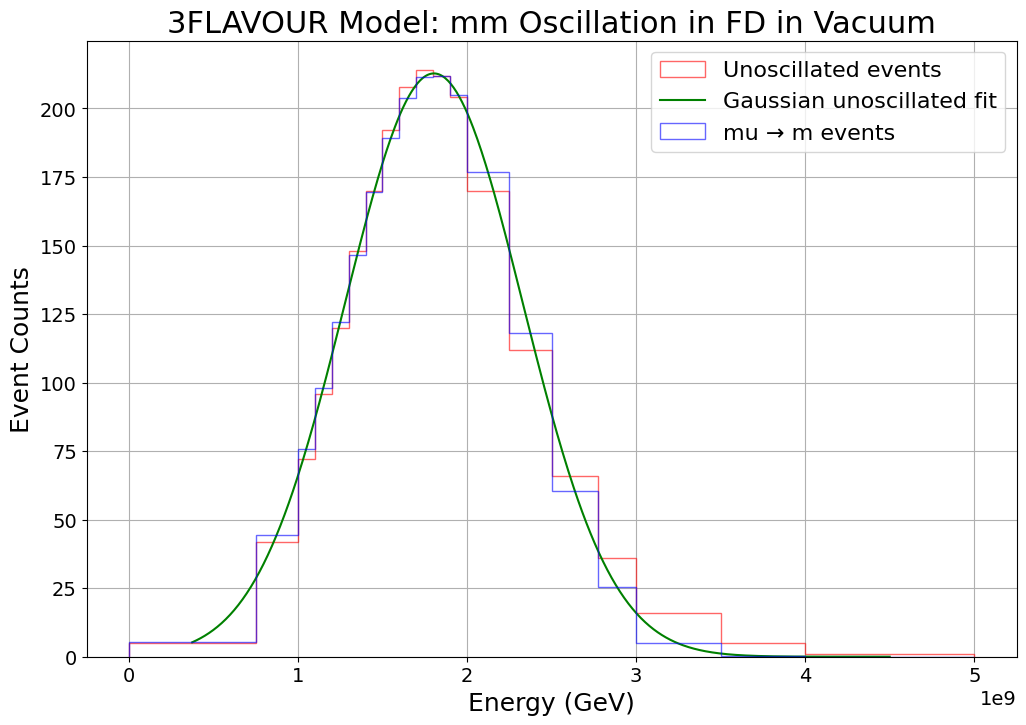

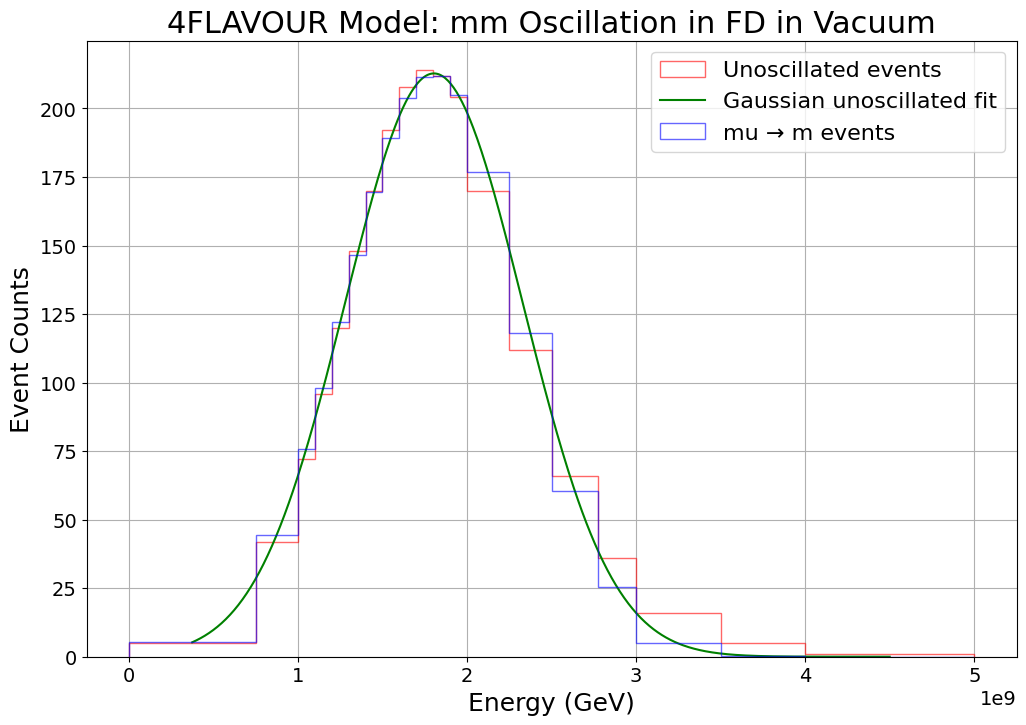

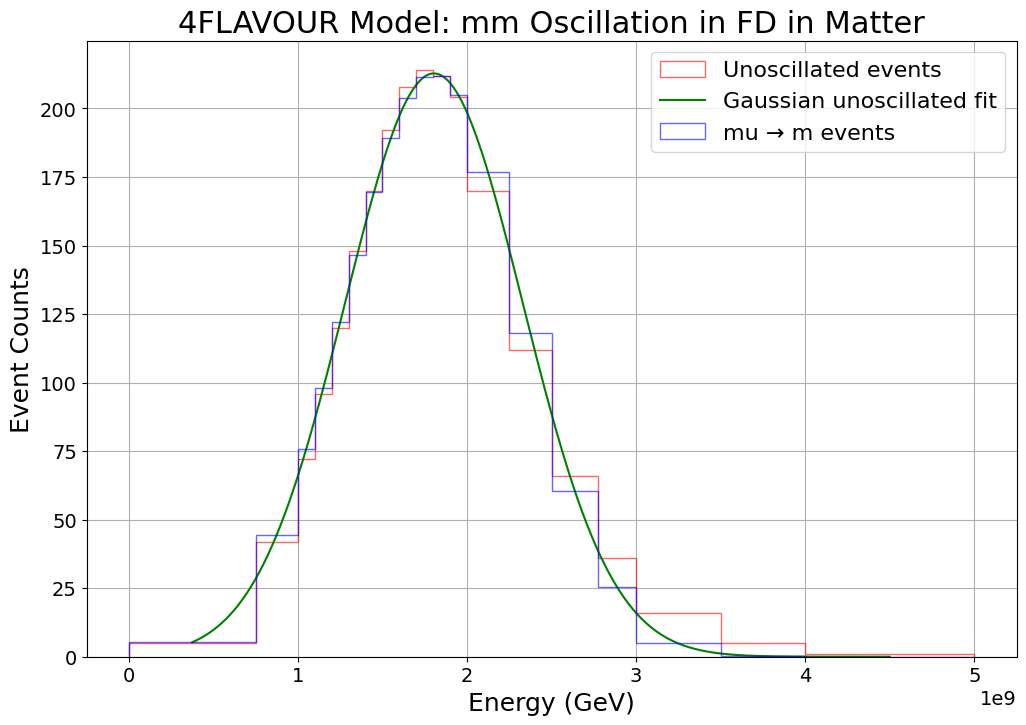

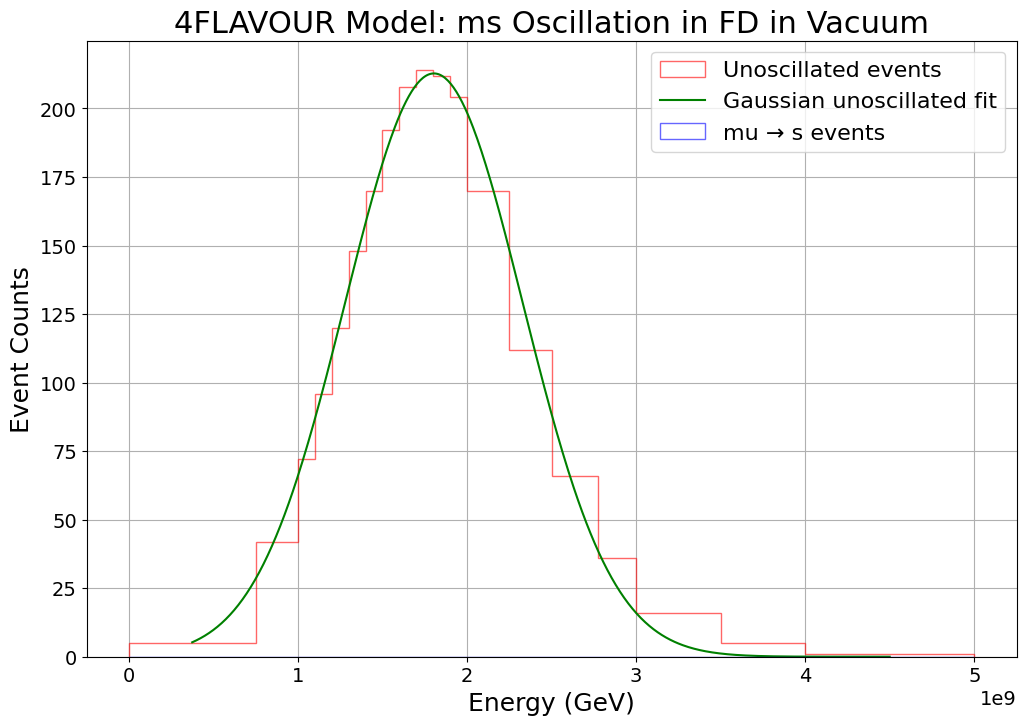

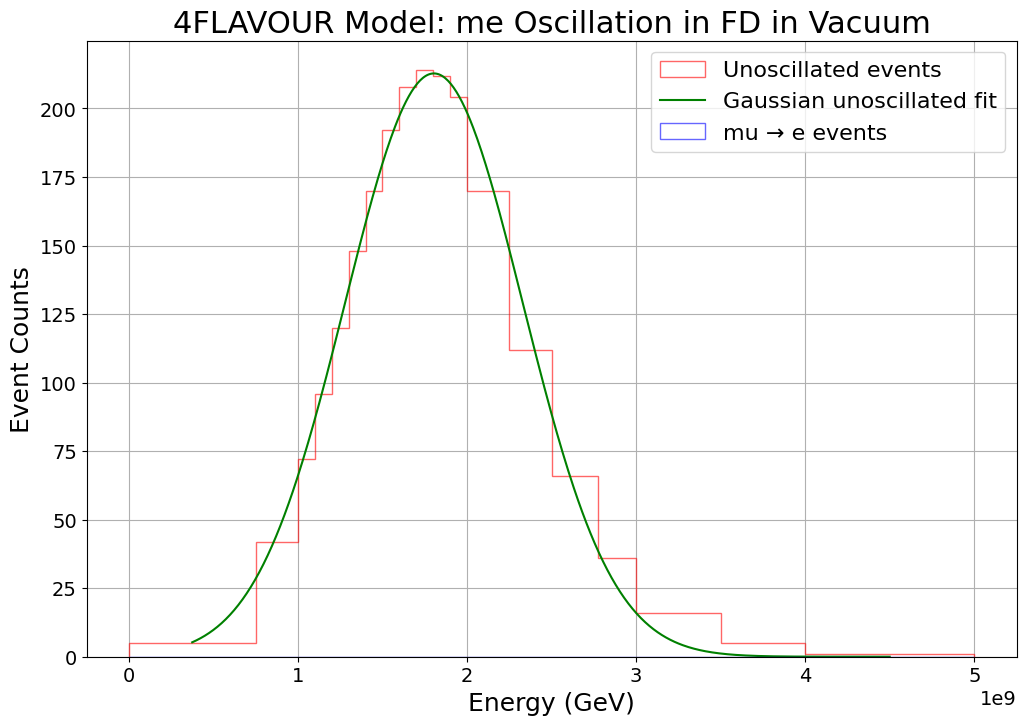

In [ ]:
# Plot muon survival probability at FD for both models
plot_osc_nu('3flavour', 'vacuum', Length_far, 'mm')
plot_osc_nu('4flavour', 'vacuum', Length_far, 'mm')

# Plot with matter effects for 4ν
plot_osc_nu('4flavour', 'matter', Length_far, 'mm')

# Other channels
plot_osc_nu('4flavour', 'vacuum', Length_far, 'ms')  # sterile appearance
plot_osc_nu('4flavour', 'vacuum', Length_far, 'me')  # electron appearance

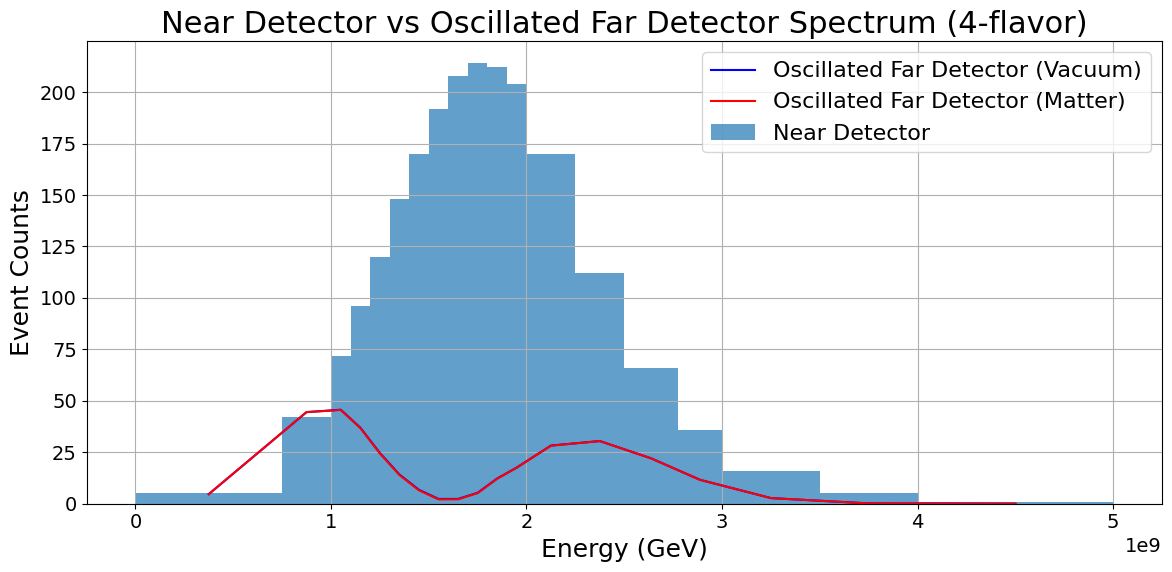

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(bin_centers, counts_nd, width=np.diff(bin_edges), align='center', alpha=0.7, label='Near Detector')
plt.plot(bin_centers, oscillated_fd_vac, 'b-', label='Oscillated Far Detector (Vacuum)')
plt.plot(bin_centers, oscillated_fd_matter, 'r-', label='Oscillated Far Detector (Matter)')
plt.xlabel("Energy (GeV)")
plt.ylabel("Event Counts")
plt.title("Near Detector vs Oscillated Far Detector Spectrum (4-flavor)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

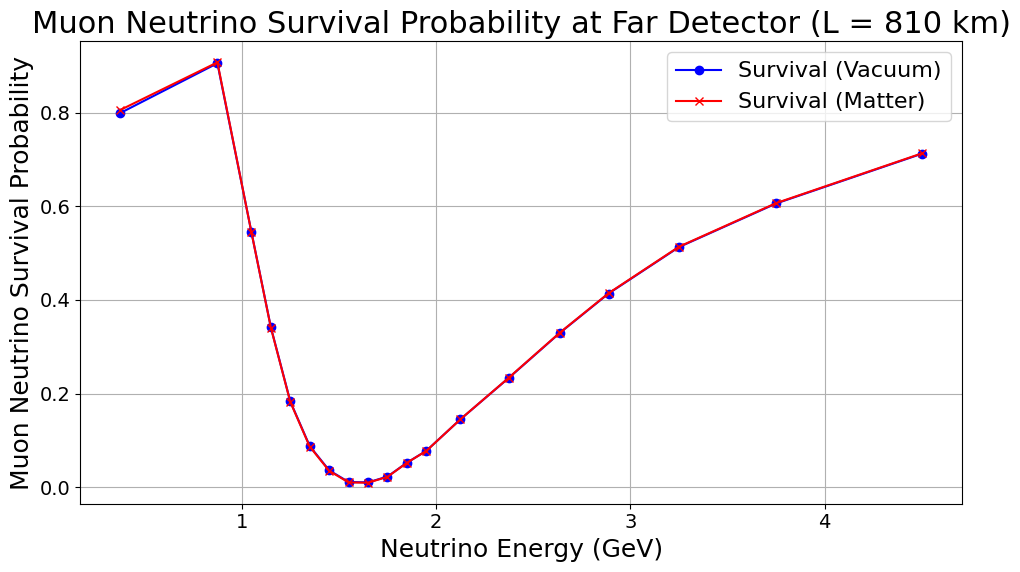

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(bin_centers * 1e-9, prob_mm_far_vac, 'b-o', label='Survival (Vacuum)')
plt.plot(bin_centers * 1e-9, prob_mm_far_matter, 'r-x', label='Survival (Matter)')
plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel("Muon Neutrino Survival Probability")
plt.title("Muon Neutrino Survival Probability at Far Detector (L = 810 km)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
